Варіант 6

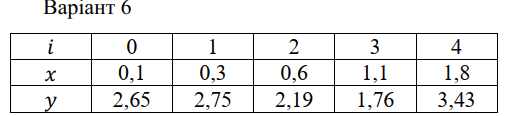

In [3]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

# Дані
x = np.array([0.1, 0.3, 0.6, 1.1, 1.8])
y = np.array([2.65, 2.75, 2.19, 1.76, 3.43])
n = len(x) - 1
h = np.diff(x)
a = y
b = np.zeros(n)
d = np.zeros(n)
c = np.zeros(n + 1) # Розширюємо на один елемент для останнього індексу c[n]

alpha = np.zeros(n)
for i in range(1, n):
  alpha[i] = (3 / h[i]) * (a[i+1] - a[i]) - (3 / h[i-1]) * (a[i] - a[i-1])

l = np.ones(n + 1) # Розширюємо l на один елемент
mu = np.zeros(n)
z = np.zeros(n + 1) # Розширюємо на один елемент

# Пряма хода для знаходження l, mu, z
for i in range(1, n):
  l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
  mu[i] = h[i] / l[i]
  z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]

# Крайова умова: c[n] = 0
l[n] = 1
z[n] = 0
c[n] = 0

# Зворотний хід для знаходження c, b, d
for j in range(n-1, -1, -1):
  c[j] = z[j] - mu[j] * c[j+1]
  b[j] = (a[j+1] - a[j]) / h[j] - h[j] * (c[j+1] + 2 * c[j]) / 3
  d[j] = (c[j+1] - c[j]) / (3 * h[j])

# Виведення аналітичного вигляду кубічного сплайну для кожного відрізка
for i in range(n):
  print(f"Відрізок {i+1}:")
  print(f"S_{i}(x) = {a[i]} + {b[i].round(4)}(x - {x[i]}) + {c[i].round(4)}(x - {x[i]})^2 + {d[i].round(4)}(x - {x[i]})^3, x належить [{x[i]}, {x[i+1]}]")

Відрізок 1:
S_0(x) = 2.65 + 1.0177(x - 0.1) + 0.0(x - 0.1)^2 + -12.9435(x - 0.1)^3, x належить [0.1, 0.3]
Відрізок 2:
S_1(x) = 2.75 + -0.5355(x - 0.3) + -7.7661(x - 0.3)^2 + 11.096(x - 0.3)^3, x належить [0.3, 0.6]
Відрізок 3:
S_2(x) = 2.19 + -2.1992(x - 0.6) + 2.2203(x - 0.6)^2 + 0.9162(x - 0.6)^3, x належить [0.6, 1.1]
Відрізок 4:
S_3(x) = 1.76 + 0.7082(x - 1.1) + 3.5946(x - 1.1)^2 + -1.7117(x - 1.1)^3, x належить [1.1, 1.8]


In [10]:
from scipy.interpolate import CubicSpline

cs = CubicSpline(x, y)

for i in range(n):
  coeffs = cs.c[:, 1]
  print(f"S_{i+1}(x) = {coeffs[0]:.4f}*(x - {x[i]})^3 + {coeffs[1]:.4f}*(x - {x[i]})^2 + {coeffs[2]:.4f}*(x - {x[i]}) + {coeffs[3]:.4f}")

S_1(x) = 8.5567*(x - 0.1)^3 + -5.5890*(x - 0.1)^2 + -0.9601*(x - 0.1) + 2.7500
S_2(x) = 8.5567*(x - 0.3)^3 + -5.5890*(x - 0.3)^2 + -0.9601*(x - 0.3) + 2.7500
S_3(x) = 8.5567*(x - 0.6)^3 + -5.5890*(x - 0.6)^2 + -0.9601*(x - 0.6) + 2.7500
S_4(x) = 8.5567*(x - 1.1)^3 + -5.5890*(x - 1.1)^2 + -0.9601*(x - 1.1) + 2.7500


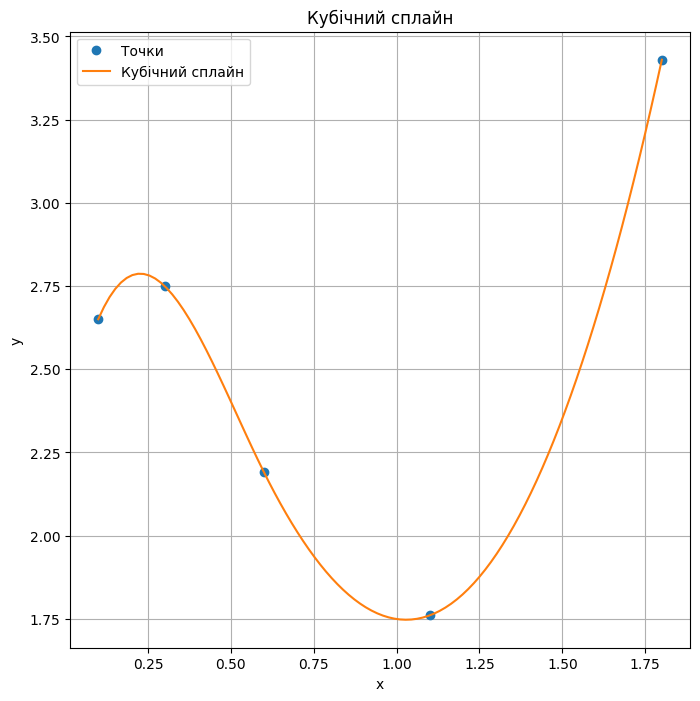

In [9]:
cs = CubicSpline(x, y)

x_new = np.linspace(np.min(x), np.max(x), 100)
y_new = cs(x_new)

plt.figure(figsize=(8, 8))
plt.plot(x, y, "o", label="Точки")
plt.plot(x_new, y_new, label="Кубічний сплайн")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Кубічний сплайн")
plt.legend()
plt.grid()
plt.show()

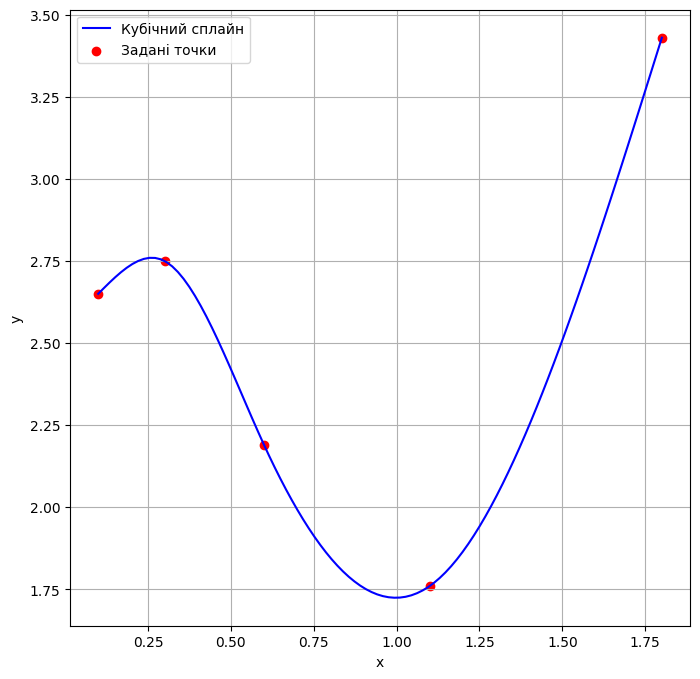

In [4]:
# Побудова графіка
x_values = np.linspace(np.min(x), np.max(x), 100) # Діапазон для побудови графіка
y_values = [ ]# Значення сплайна

# Обчислення значень сплайна для кожного відрізка
for i in range(n):
  mask = (x_values >= x[i]) & (x_values <= x[i + 1])
  x_interval = x_values[mask]
  y_interval = a[i] + b[i] * (x_interval - x[i]) + c[i] * (x_interval - x[i]) ** 2 + d[i] * (x_interval - x[i]) ** 3
  y_values.extend(y_interval)

# Побудова графіка
plt.figure(figsize=(8, 8))
plt.plot(x_values, y_values, label="Кубічний сплайн", color='b')
plt.scatter(x, y, label="Задані точки", color='r')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()